In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from mlxtend.plotting import plot_decision_regions


In [2]:
df = pd.read_csv('student_pass.csv')
print(df.shape) 
# returns a tuple of rows and columns to checck if the data is loaded.
df.head()
# return top 5 rows only.


(100, 3)


,study_hours,attendance,passed
0,7.49,41.89,0
1,19.01,78.18,1
2,14.64,58.86,0
3,11.97,70.51,1
4,3.12,94.45,1


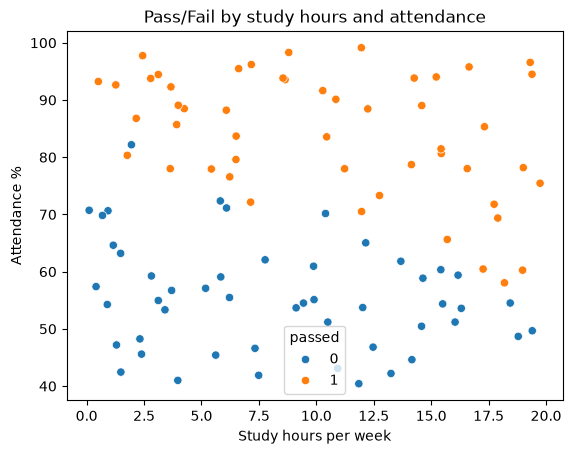

In [3]:
sns.scatterplot(x=df['study_hours'], y=df['attendance'], hue=df['passed'])
plt.xlabel('Study hours per week')
plt.ylabel('Attendance %')
plt.title('Pass/Fail by study hours and attendance')
plt.show()

In [12]:
X = df.iloc[:, 0:2] #study hours and attendance
Y = df.iloc[:, -1] #select all rows but for last column only
# ye hum data split krre hai

In [13]:

from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)
p = Perceptron(max_iter=1000, tol=1e-3)
p.fit(X_scaled,Y)
# working samjho : it loops through the data, and every time a point is misclassified, it adjusts the weights and bias to correct for it, repeating until it converges or hits the max iteration limit.

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [14]:
print(p.coef_)
print(p.intercept_) 
# coef gives the learned weights for each input and intercept is the bias b....Together they define the decision line: w1*study_hours + w2*attendance + b = 0. Points on one side get classified as pass, the other as fail.

[[3.59974126 6.22058356]]
[0.]


c:\Workspace\ml-training\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


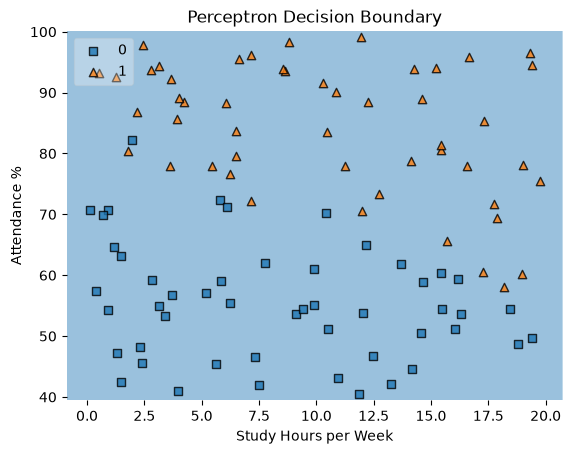

In [7]:
plot_decision_regions(X.values, Y.values, clf=p, legend=2)
plt.xlabel('Study Hours per Week')
plt.ylabel('Attendance %')
plt.title('Perceptron Decision Boundary')
plt.show()

In [15]:
from sklearn.metrics import accuracy_score
y_pred = p.predict(X_scaled)
accuracy_score(Y, y_pred)


0.93

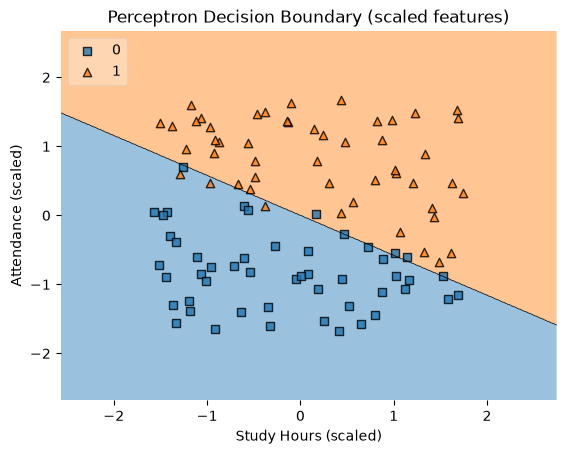

In [17]:
plot_decision_regions(X_scaled, Y.values, clf=p, legend=2)
plt.xlabel('Study Hours (scaled)')
plt.ylabel('Attendance (scaled)')
plt.title('Perceptron Decision Boundary (scaled features)')
plt.show()

In [33]:
new_student = pd.DataFrame({'study_hours': [10], 'attendance': [70]})
new_student_scaled = scaler.transform(new_student)
prediction = p.predict(new_student_scaled)
print(prediction)

[1]
